# <font color=red>**Universidad Nacional Autónoma de México**
# <font color=lightgreen>**Facultad de Ciencias**
# <font color=cyan>**Proyecto No. 1 Cuadratura Numérica Ejercicios Computacionales, semestre 2025-2**
# <font color=magenta>**problema 14**

Programar:

• Regla del Punto Medio y Regla del Punto Medio Compuesta.

• Regla del Trapecio y Regla del Trapecio Compuesta.

• Regla de Simpson y Regla de Simpson Compuesta.

• Cuadratura de Gauss.

• Integración de Romberg.

• Método de Monte Carlo.

Primero tenemos que probar si funciona bien todo

In [1]:
print("hola :)")


hola :)


Al parecer tenemos que instalar algunas paqueterias

In [6]:
# %pip install numpy matplotlib

Okay ya funciona las paqueterias numpy y matplotlib

In [3]:
# primero llamamos a las paqueterias que usaremos para
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# definimos las funciones que nos pide el problema nos pide
#___________________________________________________________________________
def regla_punto_medio(f, a, b): # el primer metodo y más sencillo para aprox. la integral a fx entre [a,b].
  """Regla del punto medio."""
  return (b - a) * f((a + b) / 2) # formula Regla del punto medio y área total aproximada
#___________________________________________________________________________
def regla_punto_medio_compuesta(f, a, b, n):
  """Regla del punto medio compuesta. Aproxima la integral de la función f(x) en el intervalo [a, b] usando n subintervalos.
      Parámetros:
    - f: La función a integrar.
    - a: El límite inferior del intervalo.
    - b: El límite superior del intervalo.
    - n: El número de subintervalos"""
  # el refinamiento del primer metodo para aprox.
  h = (b - a) / n
  suma = 0
  for i in range(n):
    suma += f(a + (i + 0.5) * h) # formula Regla del punto medio compuesta.
  return h * suma # Área total aproximada
#___________________________________________________________________________
def regla_trapecio(f, a, b):
  """Regla del trapecio.
    Calcula la longitud del intervalo [a, b], (b - a) es la longitud total del interval.
    Se divide entre 2 porque usamos los extremos a y b para formar un trapecio.
    Calcula el área del trapecio utilizando la fórmula Área = (base mayor + base menor) / 2 * altura.
    #En este caso, las "bases" son f(a) y f(b), y la "altura" es (b - a)
         Parámetros:
    - f: La función a integrar.
    - a: El límite inferior del intervalo.
    - b: El límite superior del intervalo. """
  return (b - a) / 2 * (f(a) + f(b)) # Área total aproximada
#___________________________________________________________________________
def regla_trapecio_compuesta(f, a, b, n):
    """Regla del trapecio compuesta.

    Aproxima la integral de la función f(x) en el intervalo [a, b] usando n subintervalos del trapecio.

    Parámetros:
    - f: La función a integrar.
    - a: El límite inferior del intervalo.
    - b: El límite superior del intervalo.
    - n: El número de subintervalos
    """

    # Calcula la longitud de cada subintervalo
    h = (b - a) / n  # Longitud de cada subintervalo

    # Inicializa la suma con las contribuciones de los extremos
    suma = 0.5 * (f(a) + f(b))  # Suma las evaluaciones de f en los extremos a y b, multiplicadas por 0.5

    # Itera sobre los subintervalos intermedios
    for i in range(1, n):
        # Evalúa la función en el punto del subintervalo correspondiente y suma
        suma += f(a + i * h)  # Suma el valor de f en el punto a + i * h

    # Retorna el área total aproximada multiplicando la suma por la longitud del subintervalo
    return h * suma  # Área total aproximada
#___________________________________________________________________________
def regla_simpson(f, a, b):
    """Regla de Simpson.

    Aproxima la integral de la función f(x) en el intervalo [a, b] usando la regla de Simpson.
    """
    # Calcula el área bajo la curva utilizando la fórmula de Simpson
    return (b - a) / 6 * (f(a) + 4 * f((a + b) / 2) + f(b)) # Área total aproximada

#___________________________________________________________________________
def regla_simpson_compuesta(f, a, b, n):
    """Regla de Simpson compuesta.

    Aproxima la integral de la función f(x) en el intervalo [a, b] usando n subintervalos (n debe ser par).
    """
    # Verifica que n sea par
    if n % 2 != 0:
        raise ValueError("n debe ser par para la regla de Simpson compuesta.")

    # Calcula la longitud de cada subintervalo
    h = (b - a) / n

    # Inicializa la suma con las evaluaciones de f en los extremos del intervalo
    suma = f(a) + f(b)

    # Suma los valores de f en los índices impares multiplicados por 4
    for i in range(1, n, 2):
        suma += 4 * f(a + i * h)

    # Suma los valores de f en los índices pares multiplicados por 2
    for i in range(2, n - 1, 2):
        suma += 2 * f(a + i * h)

    # Retorna el área total aproximada multiplicando la suma por h/3
    return h / 3 * suma
#___________________________________________________________________________
def cuadratura_gauss(f, a, b, n=2):
    """Cuadratura de Gauss (n=2 por defecto).

    Aproxima la integral de la función f(x) en el intervalo [a, b] usando la cuadratura de Gauss.
    """
    # Implementación para n=2
    if n == 2:
        x1 = -1 / np.sqrt(3)  # Primer punto de Gauss
        x2 = 1 / np.sqrt(3)   # Segundo punto de Gauss
        w1 = 1                 # Peso del primer punto
        w2 = 1                 # Peso del segundo punto
        # Retorna la aproximación del área total
        return (b - a) / 2 * (w1 * f((b - a) / 2 * x1 + (b + a) / 2) +
                               w2 * f((b - a) / 2 * x2 + (b + a) / 2))

        """" Tambien se puede asi
        # Función para calcular la integral usando la regla de Gauss
    def gauss_quadrature(f):
        return np.sum(pesos * f(nodos)) """

#______________________________________________________________________________________
def integracion_romberg(f, a, b, tolerancia=1e-6):
    """Integración de Romberg.

    Aproxima la integral de la función f(x) en el intervalo [a, b] utilizando la técnica de Romberg.
    """
    # Inicializa una matriz de Romberg
    R = np.zeros((10, 10))  # Dimensiones fijas para la matriz
    R[0, 0] = regla_trapecio_compuesta(f, a, b, 1)  # Primer valor

    # Rellena la matriz de Romberg
    for i in range(1, 10):
        R[i, 0] = 0.5 * (R[i - 1, 0] + regla_trapecio_compuesta(f, a, b, 2 ** i))
        for j in range(1, i + 1):
            R[i, j] = R[i, j - 1] + (R[i, j - 1] - R[i - 1, j - 1]) / (4 ** j - 1)

        # Verifica si se ha alcanzado la tolerancia deseada
        if abs(R[i, i] - R[i - 1, i - 1]) < tolerancia:
            return R[i, i]  # Retorna el resultado si cumple la tolerancia

    return R[9, 9]  # Retorna el último valor si no se alcanza la tolerancia

#________________________________________________________________________________________
def monte_carlo(f, a, b, n=10000):
    """Método de Monte Carlo.

    Aproxima la integral de la función f(x) en el intervalo [a, b] utilizando el método de Monte Carlo.
    """
    # Genera n puntos aleatorios uniformemente distribuidos entre [a, b]
    x = np.random.uniform(a, b, n)
    # Retorna la aproximación del área bajo la curva
    return (b - a) / n * np.sum(f(x))
#________________________________________________________________________________________

In [8]:
# Ejemplo de uso para probar que funcione bien
def funcion_ejemplo(x):
  return x**2

a = 0
b = 1
n = 4 #Para métodos compuestos
print("Función ejemplo: x**2 ")
print("Regla del punto medio:", regla_punto_medio(funcion_ejemplo, a, b))
print("Regla del punto medio compuesta:", regla_punto_medio_compuesta(funcion_ejemplo, a, b, n))
print("Regla del trapecio:", regla_trapecio(funcion_ejemplo, a, b))
print("Regla del trapecio compuesta:", regla_trapecio_compuesta(funcion_ejemplo, a, b, n))
print("Regla de Simpson:", regla_simpson(funcion_ejemplo, a, b))
print("Regla de Simpson compuesta:", regla_simpson_compuesta(funcion_ejemplo, a, b, n))
print("Cuadratura de Gauss:", cuadratura_gauss(funcion_ejemplo, a, b))
print("Integración de Romberg:", integracion_romberg(funcion_ejemplo, a, b))
print("Método de Monte Carlo:", monte_carlo(funcion_ejemplo, a, b))

#Regla del punto medio: 0.25
#Regla del punto medio compuesta: 0.328125
#Regla del trapecio: 0.5
#Regla del trapecio compuesta: 0.34375
#Regla de Simpson: 0.3333333333333333
#Regla de Simpson compuesta: 0.3333333333333333
#Cuadratura de Gauss: 0.3333333333333333
#Integración de Romberg: 0.3336307700939005
#Método de Monte Carlo: 0.3345500962108694  '

Función ejemplo: x**2 
Regla del punto medio: 0.25
Regla del punto medio compuesta: 0.328125
Regla del trapecio: 0.5
Regla del trapecio compuesta: 0.34375
Regla de Simpson: 0.3333333333333333
Regla de Simpson compuesta: 0.3333333333333333
Cuadratura de Gauss: 0.3333333333333333
Integración de Romberg: 0.3336307700939005
Método de Monte Carlo: 0.3390701160544213


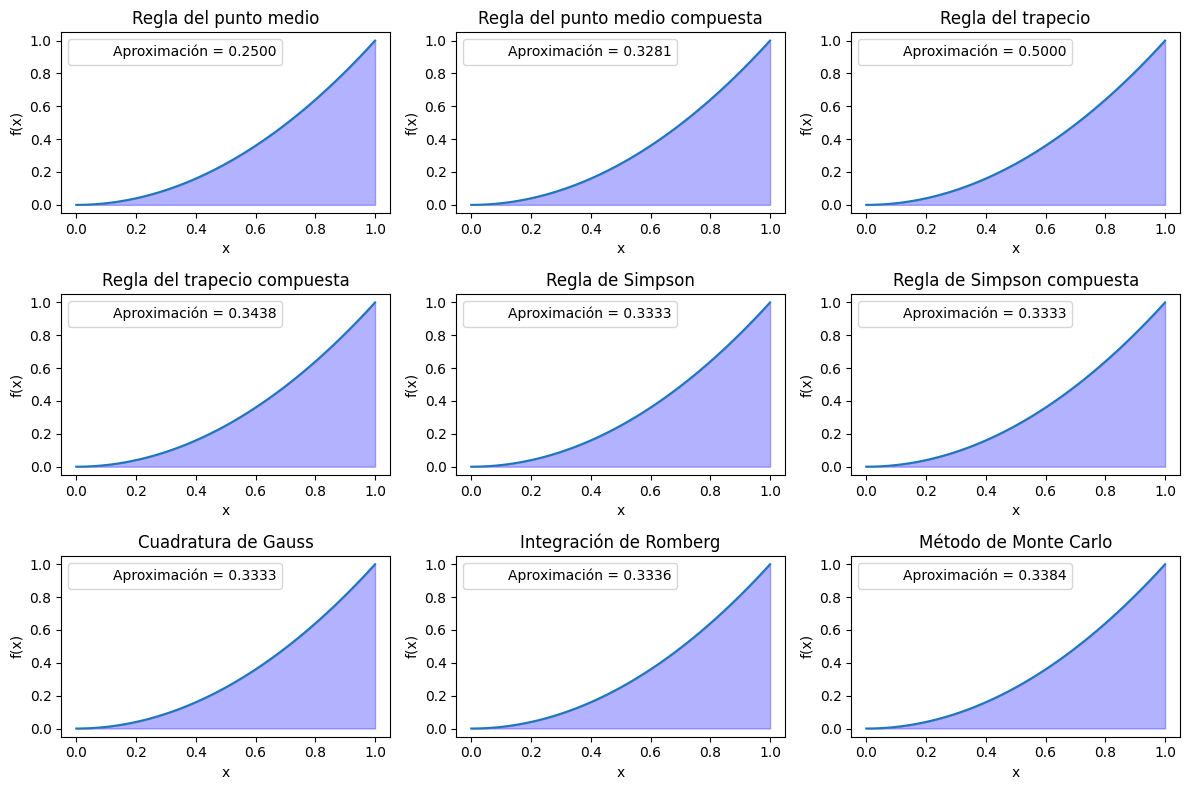

In [9]:
# Ejemplo de uso y graficación
def funcion_ejemplo(x):
    return x**2  # Función de ejemplo: f(x) = x^2

a = 0
b = 1
n = 4  # Para métodos compuestos

# Crear un rango de valores x
x = np.linspace(a, b, 100)
y = funcion_ejemplo(x)

# Configuración de la graficación
plt.figure(figsize=(12, 8))



# Graficando cada regla en un subgráfico separado

reglas = [
    (regla_punto_medio, "Regla del punto medio", 1),
    (lambda f, a, b: regla_punto_medio_compuesta(f, a, b, n), "Regla del punto medio compuesta", 2),
    (regla_trapecio, "Regla del trapecio", 3),
    (lambda f, a, b: regla_trapecio_compuesta(f, a, b, n), "Regla del trapecio compuesta", 4),
    (regla_simpson, "Regla de Simpson", 5),
    (lambda f, a, b: regla_simpson_compuesta(f, a, b, n), "Regla de Simpson compuesta", 6),
    (lambda f, a, b: cuadratura_gauss(f, a, b), "Cuadratura de Gauss", 7),
    (lambda f, a, b: integracion_romberg(f, a, b), "Integración de Romberg", 8),
    (lambda f, a, b: monte_carlo(f, a, b), "Método de Monte Carlo", 9),
]

for i, (regla, nombre_regla, num_subgrafico) in enumerate(reglas):
    aproximacion = regla(funcion_ejemplo, a, b)
    plt.subplot(3, 3, num_subgrafico)  # Crea un subgráfico en una cuadrícula de 3x3
    plt.plot(x, y)  # Grafica la función de ejemplo
    plt.fill_between(x, y, color="b", alpha=0.3)  # Rellena el área bajo la curva
    plt.title(nombre_regla)  # Título del subgráfico
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.axhline(y=aproximacion, color="r", linestyle="", label=f"Aproximación = {aproximacion:.4f}")
    plt.legend()

plt.tight_layout()  # Ajusta el espacio entre subgráficos
plt.show()  # Muestra la figura

In [10]:
# detalles mucho tiempo despues

def romberg_integration(f, a, b, n):
    """
    Integración de Romberg
    Args:
        f: función a integrar
        a: límite inferior
        b: límite superior
        n: número de filas en la tabla de Romberg
    Returns:
        Tabla de Romberg y última aproximación
    """
    r = np.zeros((n, n))
    h = b - a

    # Primera estimación trapezoidal
    r[0, 0] = 0.5 * h * (f(a) + f(b))

    for i in range(1, n):
        h /= 2
        # Calcula la suma trapezoidal refinada
        sum_f = sum(f(a + (2*k-1)*h) for k in range(1, 2**(i-1)+1))
        r[i, 0] = 0.5 * r[i-1, 0] + h * sum_f

        # Extrapolación de Richardson
        for j in range(1, i+1):
            r[i, j] = (4**j * r[i, j-1] - r[i-1, j-1]) / (4**j - 1)

    return r

# Ejemplo: integral de e^x de 0 a 2
def f(x):
    return np.exp(x)

a = 0
b = 2
n = 5

resultado = romberg_integration(f, a, b, n)

#print("Tabla de Romberg:")
#print(resultado)
#print(f"\nEstimación final: {resultado[-1, -1]:.8f}")
#print(f"Valor exacto: {np.exp(2) - 1:.8f}")

 # Función para calcular la integral usando la regla de Gauss
   # def gauss_quadrature(f):
   #     return np.sum(pesos * f(nodos))

En reseña

 El programa presentado en el notebook "problema_14.ipynb" aborda diversas técnicas de cuadratura numérica para la integración de funciones. Incluye implementaciones de la regla del punto medio, la regla del trapecio, la regla de Simpson, cuadratura de Gauss, integración de Romberg y el método de Monte Carlo. Cada método se define de manera clara y se acompaña de ejemplos prácticos que demuestran su uso. Además, se proporciona una visualización gráfica de los resultados, lo que permite una mejor comprensión de cada técnica. En conjunto, el programa ofrece una herramienta educativa valiosa para el aprendizaje de métodos de integración numérica. Todas las aproximaciones de ejemplo funcionan bien ya que sus errores son minimos, el tiempo de ejecución es minimo, tiende a tener mayor precisión los compuestos.